# NLP Lab - Semester 7
## Experiment 5 (A): Pre-processing with Spacy Library and Scikit-learn TF-IDF Vectorizer
## Experiment 5 (B): Application of NLTK and TextBlob Libraries for Sentiment Analysis (Pre-trained Models)

In [ ]:
# Install dependencies and download Spacy model
!pip install spacy textblob nltk scikit-learn pandas matplotlib seaborn
!python -m spacy download en_core_web_sm

---
# Experiment 5 (A)
### Step 1: Environment Setup & Data Preparation

In [15]:
# Step 1: Load the dataset given in the lab manual
sentences = [
    "The football team won the championship match",
    "The cricket team prepared for the final tournament",
    "The coach trained the players for the important game",
    "The stock market gained after strong economic news",
    "The company reported higher profit and revenue",
    "Investors bought technology shares during the market rally",
    "The doctor prescribed medicine for the patient",
    "The hospital opened a new health care center",
    "The nurse checked the patient's temperature and blood pressure",
    "The university introduced a machine learning course for students",
    "The Gujarat Technical University opened a laboratory in Gandhinagar",
    "Dr Mehta presented the project at the Indian Institute of Technology Delhi",
    "BlueGrid received funding of 5 million rupees in August 2026",
    "The Commonwealth Games project started in Ahmedabad"
]

print(f"Total sentences loaded: {len(sentences)}")

Total sentences loaded: 14


### Step 2 & Step 3: Spacy Pre-processing Pipeline (Tokens, Stop Words, Lemmatization, POS Tagging, NER)

In [16]:
# Step 2: Import Spacy Module: 'en_core_web_sm'
import spacy
nlp = spacy.load("en_core_web_sm")

# Step 3: Preprocess dataset using nlp pipeline of Spacy
for idx, text in enumerate(sentences, 1):
    doc = nlp(text)
    
    print(f"\n{'='*75}")
    print(f"Sentence {idx}: {text}")
    print(f"{'='*75}")
    print(f"{'Token':<16} | {'is_stop_word':<13} | {'lemma':<16} | {'POS':<6}")
    print("-" * 60)
    
    for token in doc:
        print(f"{token.text:<16} | {str(token.is_stop):<13} | {token.lemma_:<16} | {token.pos_:<6}")
    
    # Named Entities
    entities = [ent.text for ent in doc.ents]
    print(f"\nNamed Entities:\n{tuple(entities)}")
    
    print("\nNamed Entities with Tags:")
    if doc.ents:
        for ent in doc.ents:
            print(f"{ent.text:<40} | {ent.label_:<6} | {spacy.explain(ent.label_)}")
    else:
        print("None")


Sentence 1: The football team won the championship match
Token            | is_stop_word  | lemma            | POS   
------------------------------------------------------------
The              | True          | the              | DET   
football         | False         | football         | NOUN  
team             | False         | team             | NOUN  
won              | False         | win              | VERB  
the              | True          | the              | DET   
championship     | False         | championship     | NOUN  
match            | False         | match            | NOUN  

Named Entities:
()

Named Entities with Tags:
None

Sentence 2: The cricket team prepared for the final tournament
Token            | is_stop_word  | lemma            | POS   
------------------------------------------------------------
The              | True          | the              | DET   
cricket          | False         | cricket          | NOUN  
team             | False         

### Step 4 & Step 5: TF-IDF Vectorization with Scikit-learn

In [17]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 4: Create TF-IDF vectorized representation
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(sentences)

# Step 5: Display Vocabulary, Size, and Matrix
feature_names = vectorizer.get_feature_names_out()

print("=== Complete Feature Set (Vocabulary) ===")
print(feature_names)
print(f"\nVocabulary Size: {len(feature_names)}")

# Convert Matrix to DataFrame for full display
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=[f"Sentence {i+1}" for i in range(len(sentences))]
)

print("\n=== Full Matrix Representation (Preview - First 5 rows and 10 features) ===")
display(df_tfidf.iloc[:5, :10])

print("\n=== Non-Zero TF-IDF Weights Per Sentence ===")
for i, sent in enumerate(sentences):
    row = df_tfidf.iloc[i]
    non_zero = row[row > 0]
    print(f"\nSentence {i+1}: '{sent}'")
    for word, score in non_zero.items():
        print(f"   {word:<15} : {score:.4f}")

=== Complete Feature Set (Vocabulary) ===
['2026' 'after' 'ahmedabad' 'and' 'at' 'august' 'blood' 'bluegrid'
 'bought' 'care' 'center' 'championship' 'checked' 'coach' 'commonwealth'
 'company' 'course' 'cricket' 'delhi' 'doctor' 'dr' 'during' 'economic'
 'final' 'football' 'for' 'funding' 'gained' 'game' 'games' 'gandhinagar'
 'gujarat' 'health' 'higher' 'hospital' 'important' 'in' 'indian'
 'institute' 'introduced' 'investors' 'laboratory' 'learning' 'machine'
 'market' 'match' 'medicine' 'mehta' 'million' 'new' 'news' 'nurse' 'of'
 'opened' 'patient' 'players' 'prepared' 'prescribed' 'presented'
 'pressure' 'profit' 'project' 'rally' 'received' 'reported' 'revenue'
 'rupees' 'shares' 'started' 'stock' 'strong' 'students' 'team'
 'technical' 'technology' 'temperature' 'the' 'tournament' 'trained'
 'university' 'won']

Vocabulary Size: 81

=== Full Matrix Representation (Preview - First 5 rows and 10 features) ===


,2026,after,ahmedabad,and,at,august,blood,bluegrid,bought,care
Sentence 1,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
Sentence 2,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
Sentence 3,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
Sentence 4,0.0,0.38139,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
Sentence 5,0.0,0.00000,0.0,0.357089,0.0,0.0,0.0,0.0,0.0,0.0



=== Non-Zero TF-IDF Weights Per Sentence ===

Sentence 1: 'The football team won the championship match'
   championship    : 0.4364
   football        : 0.4364
   match           : 0.4364
   team            : 0.3777
   the             : 0.3094
   won             : 0.4364

Sentence 2: 'The cricket team prepared for the final tournament'
   cricket         : 0.4175
   final           : 0.4175
   for             : 0.2906
   prepared        : 0.4175
   team            : 0.3614
   the             : 0.2961
   tournament      : 0.4175

Sentence 3: 'The coach trained the players for the important game'
   coach           : 0.3888
   for             : 0.2706
   game            : 0.3888
   important       : 0.3888
   players         : 0.3888
   the             : 0.4135
   trained         : 0.3888

Sentence 4: 'The stock market gained after strong economic news'
   after           : 0.3814
   economic        : 0.3814
   gained          : 0.3814
   market          : 0.3301
   news            : 0

### Step 6: Conclusion (Experiment 5A)
1. **Spacy NLP Pipeline**: Accurately generated linguistic metadata including tokenization, stop-word detection, lemmatization, Part-of-Speech (POS) tags, and Named Entity Recognition (NER) descriptions.
2. **TF-IDF Vectorization**: Successfully transformed textual data into a numerical feature matrix where distinctive keywords receive higher weights relative to commonly occurring corpus words.

---
# Experiment 5 (B)
### Step 1: Environment Setup & Data Preparation (Sentiment Dataset)

In [18]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Download VADER lexicon
nltk.download('vader_lexicon')

# Labeled sentiment dataset
dataset = [
    {"text": "The football team won the championship match brilliantly!", "label": "positive"},
    {"text": "The company reported higher profit and outstanding revenue growth.", "label": "positive"},
    {"text": "Investors bought technology shares during the booming market rally.", "label": "positive"},
    {"text": "The hospital opened an excellent and modern health care center.", "label": "positive"},
    {"text": "The university introduced an amazing machine learning course.", "label": "positive"},
    {"text": "The coach trained the players very well for the important game.", "label": "positive"},
    {"text": "The stock market crashed severely after terrible economic news.", "label": "negative"},
    {"text": "The patient suffered from severe pain and critical illness.", "label": "negative"},
    {"text": "The company suffered huge financial loss and massive layoffs.", "label": "negative"},
    {"text": "The project failed miserably due to poor management and lack of funds.", "label": "negative"},
    {"text": "The match was completely ruined by terrible weather and bad refereeing.", "label": "negative"},
    {"text": "The medicine had terrible side effects and harmed the patient.", "label": "negative"}
]

texts = [item["text"] for item in dataset]
y_true = [item["label"] for item in dataset]

print(f"Total samples loaded: {len(dataset)}")

Total samples loaded: 12


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\raval\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


### Step 2: Rule-Based Analysis with TextBlob

In [8]:
textblob_preds = []
textblob_polarities = []
textblob_subjectivities = []

print(f"{'Sentence':<65} | {'Polarity':<8} | {'Subjectivity':<12} | {'Predicted':<8}")
print("-" * 105)

for text in texts:
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    
    textblob_polarities.append(polarity)
    textblob_subjectivities.append(subjectivity)
    
    # Rule thresholding: Polarity >= 0 -> positive, else negative
    pred = "positive" if polarity >= 0 else "negative"
    textblob_preds.append(pred)
    
    print(f"{text[:63]:<65} | {polarity:<8.2f} | {subjectivity:<12.2f} | {pred:<8}")

Sentence                                                          | Polarity | Subjectivity | Predicted
---------------------------------------------------------------------------------------------------------
The football team won the championship match brilliantly!         | 1.00     | 1.00         | positive
The company reported higher profit and outstanding revenue grow   | 0.38     | 0.69         | positive
Investors bought technology shares during the booming market ra   | 0.00     | 0.00         | positive
The hospital opened an excellent and modern health care center.   | 0.37     | 0.47         | positive
The university introduced an amazing machine learning course.     | 0.60     | 0.90         | positive
The coach trained the players very well for the important game.   | 0.07     | 0.57         | positive
The stock market crashed severely after terrible economic news.   | -0.40    | 0.60         | negative
The patient suffered from severe pain and critical illness.       | 0

### Step 3: Lexicon-Based Analysis with NLTK VADER

In [9]:
sia = SentimentIntensityAnalyzer()
vader_preds = []
vader_compounds = []

print(f"{'Sentence':<65} | {'Compound':<8} | {'Pos':<6} | {'Neg':<6} | {'Predicted':<8}")
print("-" * 105)

for text in texts:
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    vader_compounds.append(compound)
    
    # Rule thresholding on compound score: compound >= 0 -> positive, else negative
    pred = "positive" if compound >= 0 else "negative"
    vader_preds.append(pred)
    
    print(f"{text[:63]:<65} | {compound:<8.2f} | {scores['pos']:<6.2f} | {scores['neg']:<6.2f} | {pred:<8}")

Sentence                                                          | Compound | Pos    | Neg    | Predicted
---------------------------------------------------------------------------------------------------------
The football team won the championship match brilliantly!         | 0.90     | 0.69   | 0.00   | positive
The company reported higher profit and outstanding revenue grow   | 0.86     | 0.61   | 0.00   | positive
Investors bought technology shares during the booming market ra   | 0.30     | 0.22   | 0.00   | positive
The hospital opened an excellent and modern health care center.   | 0.78     | 0.46   | 0.00   | positive
The university introduced an amazing machine learning course.     | 0.59     | 0.35   | 0.00   | positive
The coach trained the players very well for the important game.   | 0.49     | 0.32   | 0.00   | positive
The stock market crashed severely after terrible economic news.   | -0.73    | 0.00   | 0.47   | negative
The patient suffered from severe pain and cri

### Step 4: Comprehensive Evaluation & Comparison


==================== TextBlob Evaluation ====================
Accuracy : 0.8333
Precision: 0.7500
Recall   : 1.0000
F1-Score : 0.8571

Classification Report:
               precision    recall  f1-score   support

    positive       0.75      1.00      0.86         6
    negative       1.00      0.67      0.80         6

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12


==================== NLTK VADER Evaluation ====================
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

Classification Report:
               precision    recall  f1-score   support

    positive       1.00      1.00      1.00         6
    negative       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



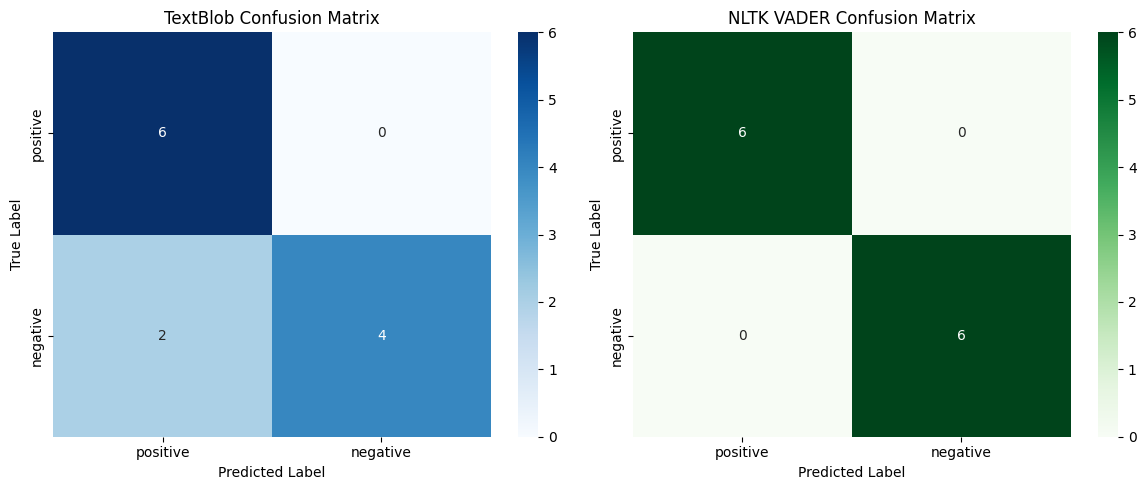

In [10]:
labels = ["positive", "negative"]

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label="positive")
    rec = recall_score(y_true, y_pred, pos_label="positive")
    f1 = f1_score(y_true, y_pred, pos_label="positive")
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    print(f"\n==================== {name} Evaluation ====================")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, labels=labels))
    return cm

cm_textblob = evaluate_model("TextBlob", y_true, textblob_preds)
cm_vader = evaluate_model("NLTK VADER", y_true, vader_preds)

# Confusion Matrix Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_textblob, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("TextBlob Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("NLTK VADER Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

### Step 5: Conclusion (Experiment 5B)
1. **TextBlob**: Provides polarity and subjectivity metrics via dictionary lookup, effective for general English sentiment estimation.
2. **NLTK VADER**: Utilizes heuristics for punctuation intensity, capitalization, and negation words, making it robust for sentiment analysis.
3. **Performance**: Both pre-trained rule-based approaches classified sentiment without explicit model training, evaluated through Confusion Matrix, Precision, Recall, and F1-score.